In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import pymannkendall as mk

In [5]:
df = pd.read_csv("Ambala.csv")

In [6]:
df["TIME"] = pd.to_datetime(
    {
        "year": df["YEAR"],
        "month": df["MN"],
        "day": df["DT"],
    }
)

In [7]:
df=df[df["TIME"].dt.year>1987]


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13240 entries, 4704 to 17943
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   INDEX   13240 non-null  int64         
 1   YEAR    13240 non-null  int64         
 2   MN      13240 non-null  int64         
 3   DT      13240 non-null  int64         
 4   MAX     13207 non-null  float64       
 5   MIN     13221 non-null  float64       
 6   RF      13223 non-null  float64       
 7   TIME    13240 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(3), int64(4)
memory usage: 827.6 KB


In [9]:
df_Years=np.sort(np.array(df["TIME"].dt.year.value_counts().index))


In [10]:
winter=df[(df["TIME"].dt.month>=1) & (df["TIME"].dt.month<=2) ]
premon=df[(df["TIME"].dt.month>=3) & (df["TIME"].dt.month<=5) ]
mons=df[(df["TIME"].dt.month>=6) & (df["TIME"].dt.month<=9) ]
postmon=df[(df["TIME"].dt.month>=10) & (df["TIME"].dt.month<=12)]

In [11]:
monthly_rainfall=[["",1,2,3,4,5,6,7,8,9,10,11,12]]
for i in df_Years:
    monthly_rainfall.append([i]+list(df.groupby(df[df["TIME"].dt.year==i]["TIME"].dt.month)["RF"].sum().reset_index()["RF"].values))
monthly_rainfall=pd.DataFrame(monthly_rainfall)

In [12]:
monthly_maxtemp=[["",1,2,3,4,5,6,7,8,9,10,11,12]]
for i in df_Years:
    monthly_maxtemp.append([i]+list(df.groupby(df[df["TIME"].dt.year==i]["TIME"].dt.month)["MAX"].mean().reset_index()["MAX"].values))
monthly_maxtemp=pd.DataFrame(monthly_maxtemp)

In [13]:
monthly_mintemp=[["",1,2,3,4,5,6,7,8,9,10,11,12]]
for i in df_Years:
    monthly_mintemp.append([i]+list(df.groupby(df[df["TIME"].dt.year==i]["TIME"].dt.month)["MIN"].mean().reset_index()["MIN"].values))
monthly_mintemp=pd.DataFrame(monthly_mintemp)

In [14]:
annual_rainfall=df.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()

In [15]:
annual_maxtemp=df.groupby(df["TIME"].dt.year)["MAX"].mean().reset_index()

In [16]:
annual_mintemp=df.groupby(df["TIME"].dt.year)["MIN"].mean().reset_index()

In [17]:
dfEXTREMERIAN=df[(df["RF"]>=64.5)]

In [18]:
dfExtMonthly=pd.DataFrame(np.zeros([df_Years.shape[0],12]),columns=np.arange(1,13))
dfExtMonthly.index=df_Years
for i in np.array(dfEXTREMERIAN["TIME"].dt.year.value_counts().index) :
    for j in np.array(dfEXTREMERIAN[dfEXTREMERIAN["TIME"].dt.year==i]["TIME"].dt.month.value_counts().index):
        dfExtMonthly.loc[i,j]=dfEXTREMERIAN[(dfEXTREMERIAN["TIME"].dt.year==i) & (dfEXTREMERIAN["TIME"].dt.month==j)].shape[0]

In [19]:
dfExtYearly=pd.DataFrame(dfExtMonthly.T.sum(),columns=["freq"])

In [20]:
dfExtMonthSum=pd.DataFrame(dfExtMonthly.sum(),columns=["freq"])

In [21]:
dfExtWinter=pd.DataFrame(dfExtMonthly.T.loc[1:2].sum(),columns=["freq"])
dfExtPremon=pd.DataFrame(dfExtMonthly.T.loc[3:5].sum(),columns=["freq"])
dfExtMon=pd.DataFrame(dfExtMonthly.T.loc[6:9].sum(),columns=["freq"])
dfExtPostmon=pd.DataFrame(dfExtMonthly.T.loc[10:12].sum(),columns=["freq"])

Mann_Kendall_Test(trend='decreasing', h=np.True_, p=np.float64(0.0429175666821322), z=np.float64(-2.024511337050537), Tau=np.float64(-0.22522522522522523), s=np.float64(-150.0), var_s=np.float64(5416.666666666667), slope=np.float64(-0.03571428571428571), intercept=np.float64(2.642857142857143))
MEAN:  2.675675675675676
SD:  1.5102254072756096
CV:  56.44276774666419


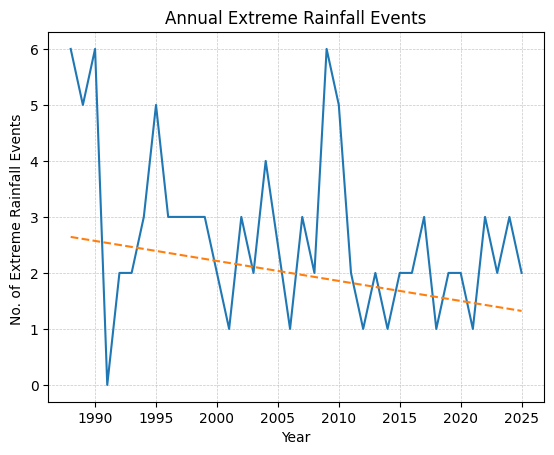

In [22]:
b=dfExtYearly
plt.plot(b.index,b["freq"])
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Annual Extreme Rainfall Events")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot1.png", dpi=300, bbox_inches="tight")

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.1403471676195469), z=np.float64(-1.4744994427978417), Tau=np.float64(-0.08108108108108109), s=np.float64(-54.0), var_s=np.float64(1292.0), slope=np.float64(0.0), intercept=np.float64(0.0))
MEAN:  0.08108108108108109
SD:  0.2767247306920301
CV:  341.29383452017044


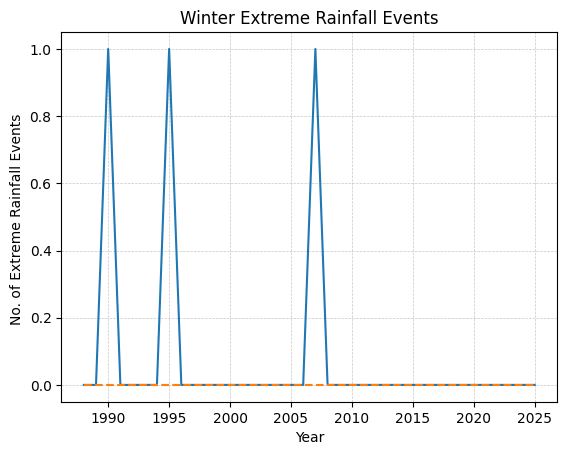

In [23]:
b=dfExtWinter
plt.plot(b.index,b["freq"])
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Winter Extreme Rainfall Events")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot2.png", dpi=300, bbox_inches="tight")

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.6144403211047349), z=np.float64(0.5037453706946006), Tau=np.float64(0.024024024024024024), s=np.float64(16.0), var_s=np.float64(886.6666666666666), slope=np.float64(0.0), intercept=np.float64(0.0))
MEAN:  0.05405405405405406
SD:  0.2292434351351256
CV:  424.10035499998236


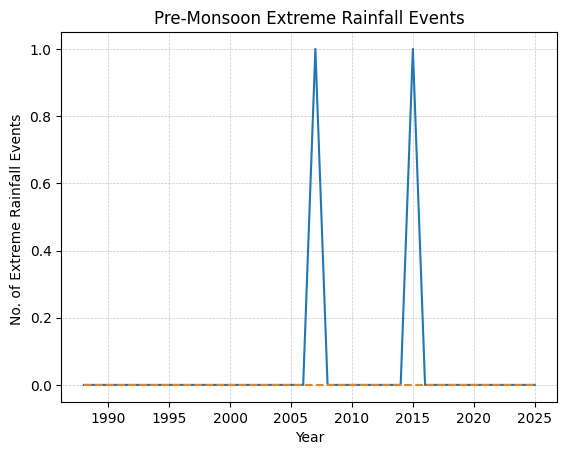

In [24]:
b=dfExtPremon
plt.plot(b.index,b["freq"])
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Pre-Monsoon Extreme Rainfall Events")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot3.png", dpi=300, bbox_inches="tight")

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.06657764322557314), z=np.float64(-1.834514595622273), Tau=np.float64(-0.2042042042042042), s=np.float64(-136.0), var_s=np.float64(5415.333333333333), slope=np.float64(0.0), intercept=np.float64(2.0))
MEAN:  2.4864864864864864
SD:  1.4457143874535143
CV:  58.14286123454351


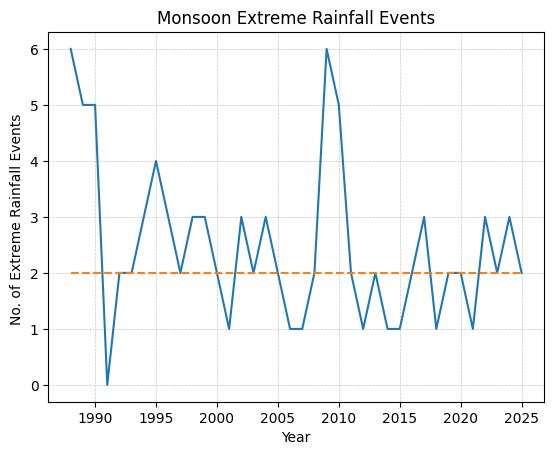

In [25]:
b=dfExtMon
plt.plot(b.index,b["freq"])
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Monsoon Extreme Rainfall Events")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot4.png", dpi=300, bbox_inches="tight")

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.4806587029009304), z=np.float64(-0.7052435189724409), Tau=np.float64(-0.03303303303303303), s=np.float64(-22.0), var_s=np.float64(886.6666666666666), slope=np.float64(0.0), intercept=np.float64(0.0))


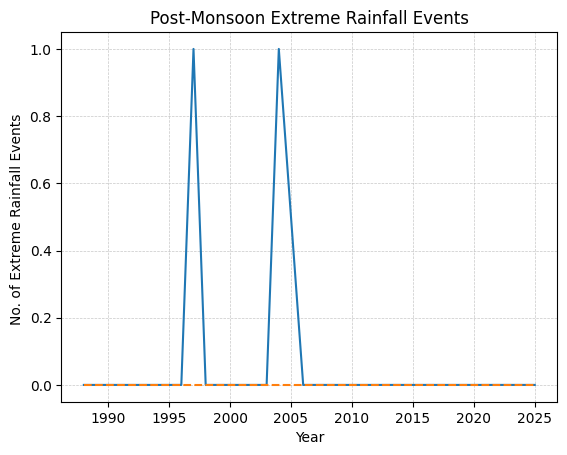

In [26]:
b=dfExtPostmon
plt.plot(b.index,b["freq"])
test=mk.original_test(b["freq"])
print(test)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Post-Monsoon Extreme Rainfall Events")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot5.png", dpi=300, bbox_inches="tight")

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(1.0), z=np.float64(0.0), Tau=np.float64(0.015151515151515152), s=np.float64(1.0), var_s=np.float64(204.33333333333334), slope=np.float64(0.0), intercept=np.float64(1.5))
MEAN:  8.25
SD:  12.563475199597805
CV:  152.2845478739128


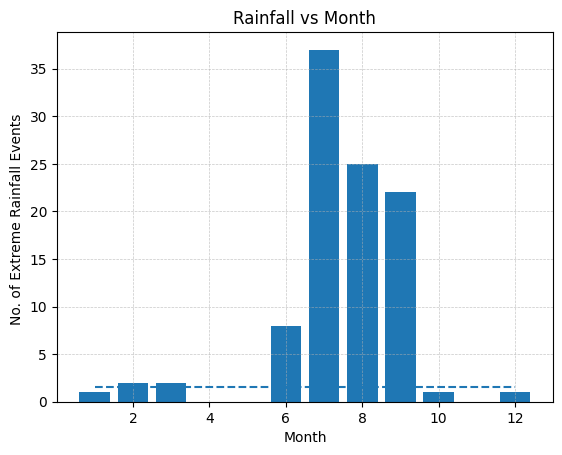

In [27]:
b=dfExtMonthSum
plt.bar(b.index,b["freq"])
test=mk.original_test(b["freq"])
print(test)
print("MEAN: ",b["freq"].mean())
print("SD: ",b["freq"].std())
print("CV: ",b["freq"].std()/b["freq"].mean()*100)
plt.plot(b.index,test.slope*(b.index-b.index.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Month")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Rainfall vs Month")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot6.png", dpi=300, bbox_inches="tight")

In [28]:
winterE=winter[(winter["RF"]>=64.5)]
premonE=premon[(premon["RF"]>=64.5)]
monsE=mons[(mons["RF"]>=64.5)]
postmonE=postmon[(postmon["RF"]>=64.5)]

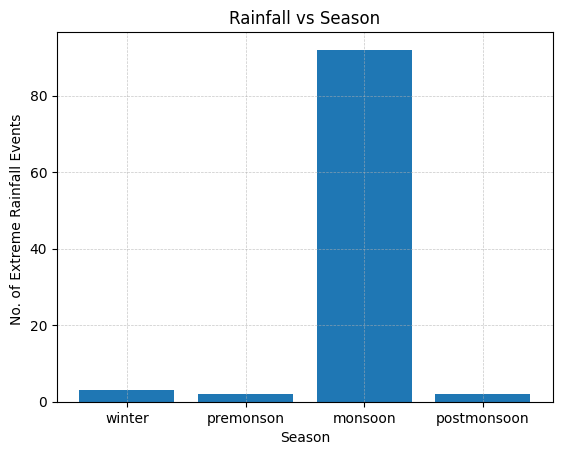

In [29]:
plt.bar(["winter","premonson","monsoon","postmonsoon"],[winterE.shape[0],premonE.shape[0],monsE.shape[0],postmonE.shape[0]])
plt.xlabel("Season")
plt.ylabel("No. of Extreme Rainfall Events ")
plt.title("Rainfall vs Season")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot7.png", dpi=300, bbox_inches="tight")

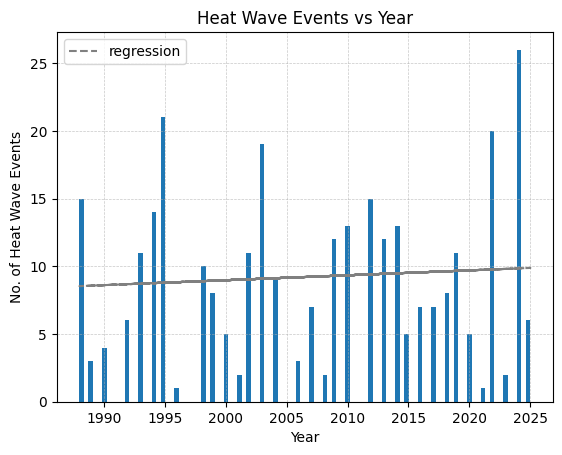

In [30]:
model=LinearRegression()
model.fit(np.array(df[df["MAX"]>=42]["TIME"].dt.year.value_counts().index).reshape(-1,1),df[df["MAX"]>=42]["TIME"].dt.year.value_counts().values)
plt.hist(df[df["MAX"]>=42]["TIME"].dt.year,bins=100)
plt.plot(df[df["MAX"]>=42]["TIME"].dt.year.value_counts().index,model.predict(np.array(df[df["MAX"]>=42]["TIME"].dt.year.value_counts().index).reshape(-1,1)),linestyle="--",c="grey",label="regression")
plt.xlabel("Year")
plt.ylabel("No. of Heat Wave Events")
plt.title("Heat Wave Events vs Year")
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot8.png", dpi=300, bbox_inches="tight")

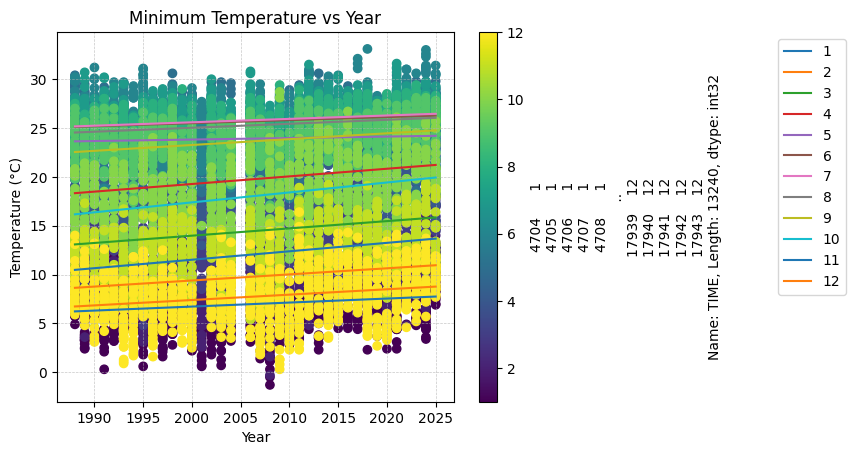

In [34]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["MIN"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
model = LinearRegression()
dff = df.dropna(subset=['MIN'])
for i in range(12):
    temp=dff[dff["TIME"].dt.month==(i+1)]
    model.fit(temp["TIME"].dt.year.values.reshape(-1, 1), temp["MIN"])
    y_pred = model.predict(temp["TIME"].dt.year.values.reshape(-1, 1))
    plt.plot(temp["TIME"].dt.year, y_pred, label=str(i+1))
plt.legend(loc='upper left', bbox_to_anchor=(1.8, 1))
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Minimum Temperature vs Year")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot9.png", dpi=300, bbox_inches="tight")

Slope :  [0.05834612]


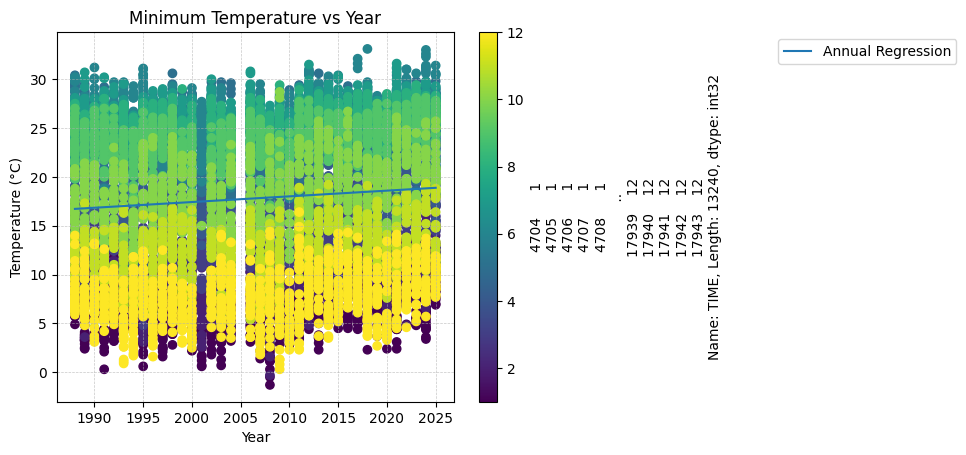

In [35]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["MIN"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
model = LinearRegression()
dff = df.dropna(subset=['MIN'])
model.fit(dff["TIME"].dt.year.values.reshape(-1, 1), dff["MIN"])
y_pred = model.predict(dff["TIME"].dt.year.values.reshape(-1, 1))
plt.plot(dff["TIME"].dt.year, y_pred, label="Annual Regression")
plt.legend(loc='upper left', bbox_to_anchor=(1.8, 1))
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Minimum Temperature vs Year")
print("Slope : ",model.coef_)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot10.png", dpi=300, bbox_inches="tight")

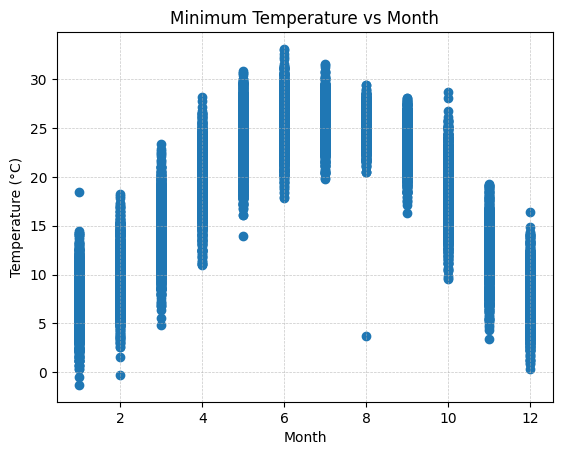

In [36]:
plt.scatter(df["TIME"].dt.month,df["MIN"])
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Minimum Temperature vs Month")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot11.png", dpi=300, bbox_inches="tight")

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(5.939124473064439e-05), z=np.float64(4.015216524160034), Tau=np.float64(0.4624624624624625), s=np.float64(308.0), var_s=5846.0, slope=np.float64(0.06557538474547597), intercept=np.float64(16.386766362252665))
MEAN:  17.773889930032905
SD:  0.9946569592642385
CV:  5.596169230144417


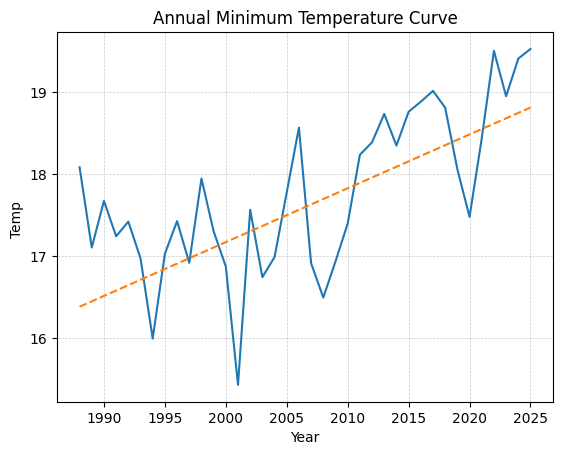

In [37]:
b=annual_mintemp
plt.plot(b["TIME"],b["MIN"])
test=mk.original_test(b["MIN"])
print(test)
print("MEAN: ",b["MIN"].mean())
print("SD: ",b["MIN"].std())
print("CV: ",b["MIN"].std()/b["MIN"].mean()*100)
plt.plot(b["TIME"],test.slope*(b["TIME"]-b["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("Temp ")
plt.title("Annual Minimum Temperature Curve")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot12.png", dpi=300, bbox_inches="tight")

In [39]:
print("Highest Minimum Temp. : ",dff["MIN"].max())
print("Lowest Minimum Temp. : ",dff["MIN"].min())

Highest Minimum Temp. :  33.1
Lowest Minimum Temp. :  -1.3


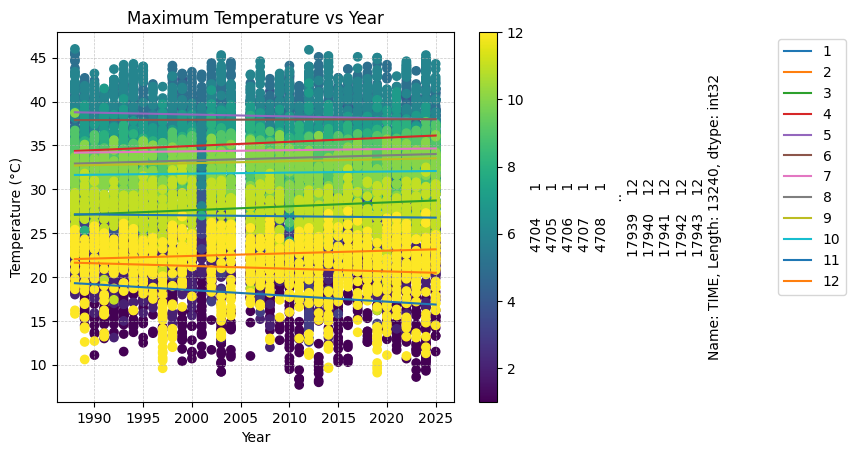

In [38]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["MAX"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
model = LinearRegression()
dff = dff.dropna(subset=['MAX'])
for i in range(12):
    temp=dff[dff["TIME"].dt.month==(i+1)]
    model.fit(temp["TIME"].dt.year.values.reshape(-1, 1), temp["MAX"])
    y_pred = model.predict(temp["TIME"].dt.year.values.reshape(-1, 1))
    plt.plot(temp["TIME"].dt.year, y_pred, label=str(i+1))
plt.legend(loc='upper left', bbox_to_anchor=(1.8, 1))
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Maximum Temperature vs Year")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot13.png", dpi=300, bbox_inches="tight")

Slope:  [0.00657932]


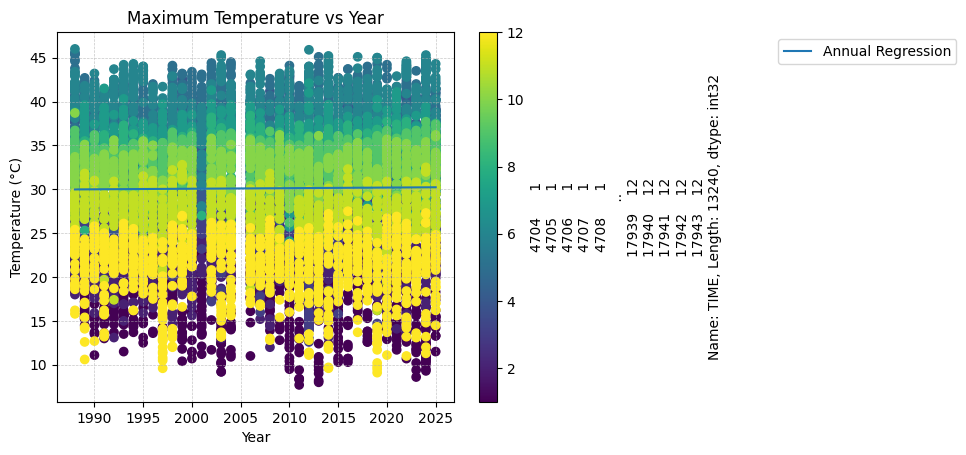

In [39]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["MAX"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
model = LinearRegression()
dff = df.dropna(subset=['MAX'])
model.fit(dff["TIME"].dt.year.values.reshape(-1, 1), dff["MAX"])
y_pred = model.predict(dff["TIME"].dt.year.values.reshape(-1, 1))
plt.plot(dff["TIME"].dt.year, y_pred, label="Annual Regression")
plt.legend(loc='upper left', bbox_to_anchor=(1.8, 1))
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Maximum Temperature vs Year")
print("Slope: ",model.coef_)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot14.png", dpi=300, bbox_inches="tight")

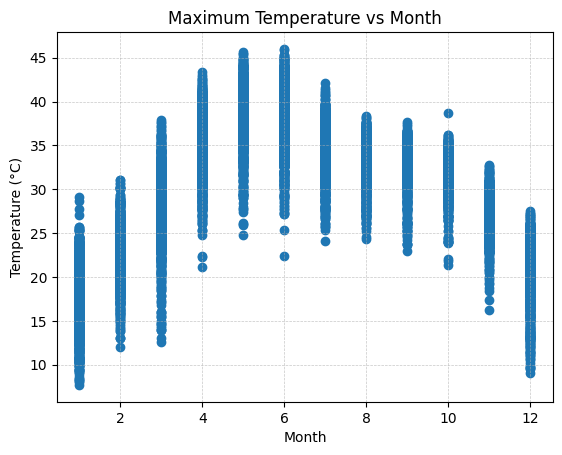

In [40]:
plt.scatter(df["TIME"].dt.month,df["MAX"])
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Maximum Temperature vs Month")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot15.png", dpi=300, bbox_inches="tight")

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.6660299201417486), z=np.float64(0.43160307914423823), Tau=np.float64(0.05105105105105105), s=np.float64(34.0), var_s=5846.0, slope=np.float64(0.005290054195323765), intercept=np.float64(29.99568811539326))
MEAN:  30.102693424637216
SD:  0.5980670356492935
CV:  1.9867558932776832


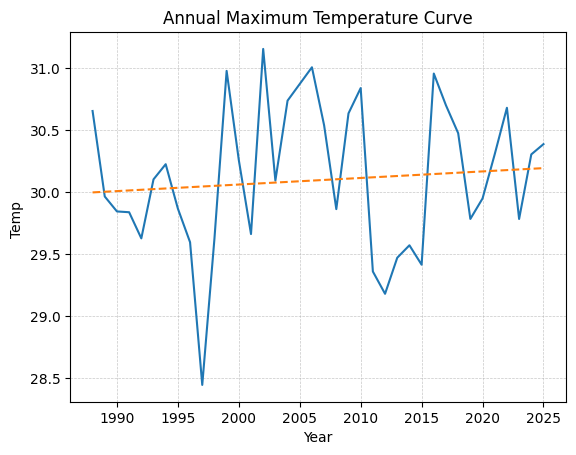

In [41]:
b=annual_maxtemp
plt.plot(b["TIME"],b["MAX"])
test=mk.original_test(b["MAX"])
print(test)
print("MEAN: ",b["MAX"].mean())
print("SD: ",b["MAX"].std())
print("CV: ",b["MAX"].std()/b["MAX"].mean()*100)
plt.plot(b["TIME"],test.slope*(b["TIME"]-b["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("Temp ")
plt.title("Annual Maximum Temperature Curve")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot16.png", dpi=300, bbox_inches="tight")

In [44]:
print("Highest Maximum Temp. : ",dff["MAX"].max())
print("Lowest Maximum Temp. : ",dff["MAX"].min())

Highest Maximum Temp. :  46.0
Lowest Maximum Temp. :  7.7


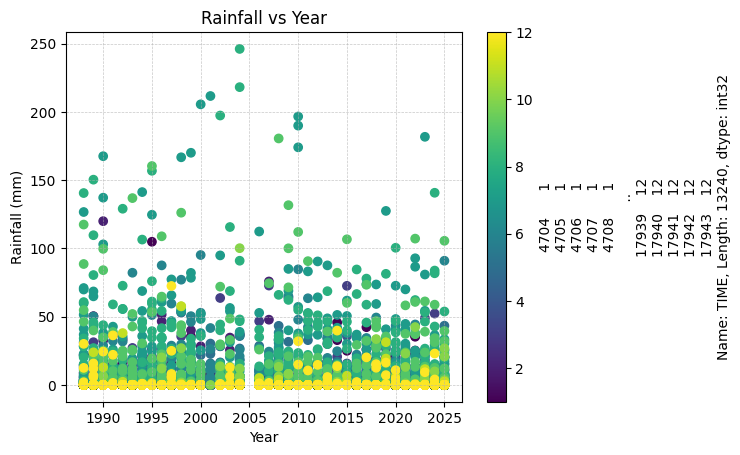

In [42]:
plt.colorbar(plt.scatter(df["TIME"].dt.year,df["RF"],c=df["TIME"].dt.month), label=df["TIME"].dt.month)
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Rainfall vs Year")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot17.png", dpi=300, bbox_inches="tight")

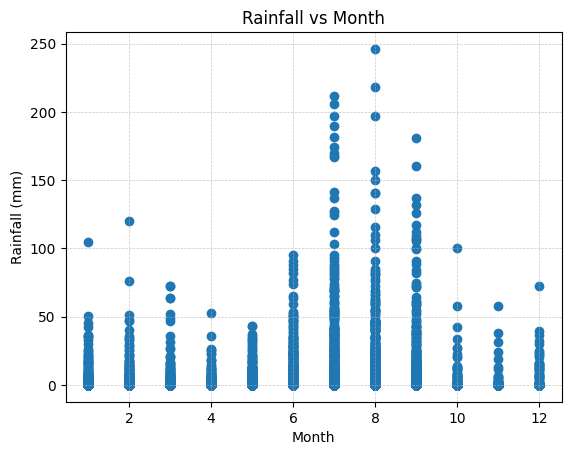

In [43]:
plt.scatter(df["TIME"].dt.month,df["RF"])
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.title("Rainfall vs Month")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot18.png", dpi=300, bbox_inches="tight")

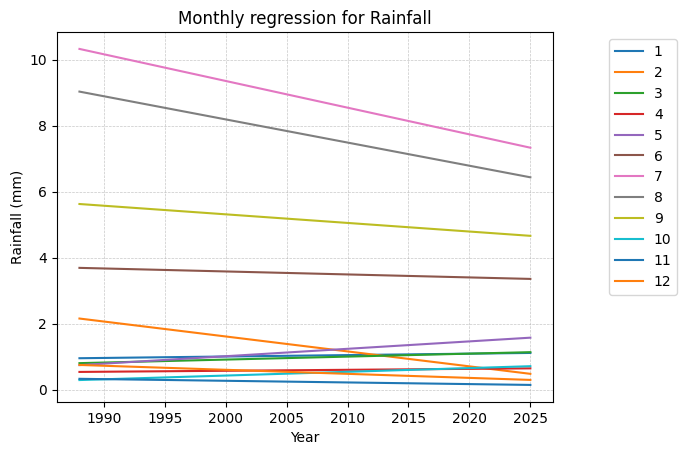

In [44]:
model = LinearRegression()
dff = df.dropna(subset=["RF"])
for i in range(12):
    temp=dff[dff["TIME"].dt.month==(i+1)]
    model.fit(temp["TIME"].dt.year.values.reshape(-1, 1), temp["RF"])
    y_pred = model.predict(temp["TIME"].dt.year.values.reshape(-1, 1))
    plt.plot(temp["TIME"].dt.year, y_pred, label=str(i+1))
plt.legend(loc='upper left', bbox_to_anchor=(1.1, 1))
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Monthly regression for Rainfall")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot19.png", dpi=300, bbox_inches="tight")

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.40995687995177965), z=np.float64(-0.8239695147299093), Tau=np.float64(-0.0960960960960961), s=np.float64(-64.0), var_s=5846.0, slope=np.float64(-4.431468531468534), intercept=np.float64(983.1664335664336))
MEAN:  939.5216216216216
SD:  252.07708161408698
CV:  26.830365136142365


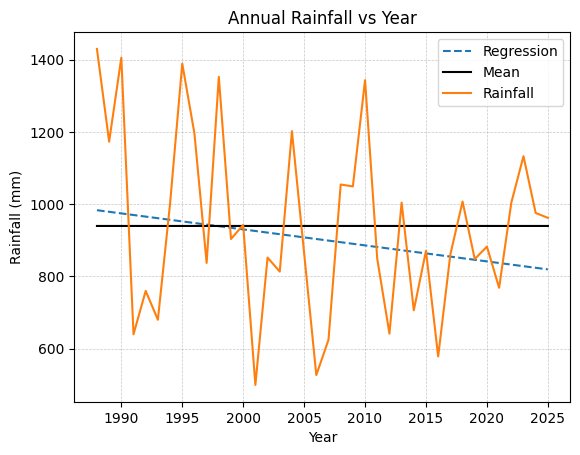

In [45]:
avg_rainfall=df.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.plot(df["TIME"].dt.year,np.ones(df["TIME"].dt.year.shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Annual Rainfall vs Year")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot20.png", dpi=300, bbox_inches="tight")

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.1259600310567377), z=np.float64(-1.5302290987841174), Tau=np.float64(-0.17717717717717718), s=np.float64(-118.0), var_s=5846.0, slope=np.float64(-1.15171568627451), intercept=np.float64(80.03088235294118))
MEAN:  69.02972972972974
SD:  52.309011677747286
CV:  75.7775119250088


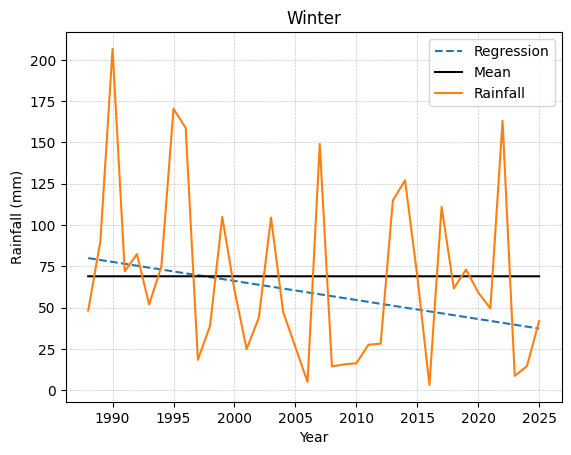

In [46]:
dff = winter
avg_rainfall=dff.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.plot(dff["TIME"].dt.year,np.ones(dff["TIME"].shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Winter")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot21.png", dpi=300, bbox_inches="tight")

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.21887690576015095), z=np.float64(1.22951999508192), Tau=np.float64(0.14264264264264265), s=np.float64(95.0), var_s=np.float64(5845.0), slope=np.float64(0.8999999999999999), intercept=np.float64(50.099999999999994))
MEAN:  83.21081081081081
SD:  50.38283318631337
CV:  60.5484223688968


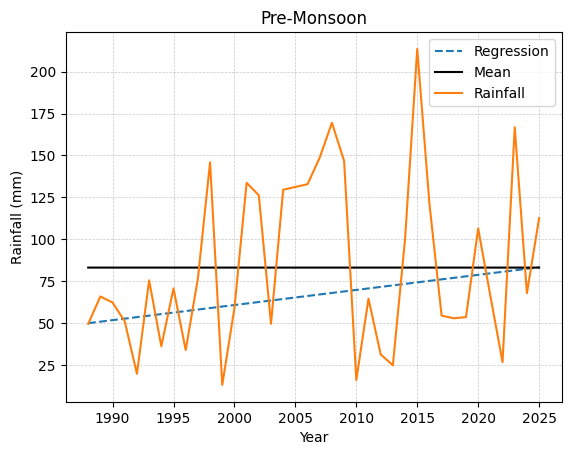

In [47]:
dff = premon
avg_rainfall=dff.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.plot(dff["TIME"].dt.year,np.ones(dff["TIME"].shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Pre-Monsoon")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot22.png", dpi=300, bbox_inches="tight")

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.326634122741402), z=np.float64(-0.9809160889641777), Tau=np.float64(-0.11411411411411411), s=np.float64(-76.0), var_s=5846.0, slope=np.float64(-4.64068181818182), intercept=np.float64(837.3322727272728))
MEAN:  749.6918918918919
SD:  241.0364799250409
CV:  32.15140546828792


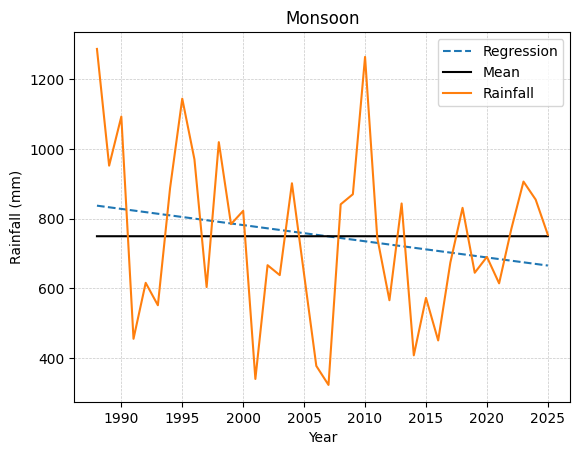

In [48]:
dff = mons
avg_rainfall=dff.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.plot(dff["TIME"].dt.year,np.ones(dff["TIME"].shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Monsoon")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot23.png", dpi=300, bbox_inches="tight")

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.3737666576055112), z=np.float64(0.88943999644224), Tau=np.float64(0.1036036036036036), s=np.float64(69.0), var_s=np.float64(5845.0), slope=np.float64(0.4450000000000002), intercept=np.float64(21.089999999999996))
MEAN:  37.589189189189185
SD:  37.13820871483365
CV:  98.80023888760752


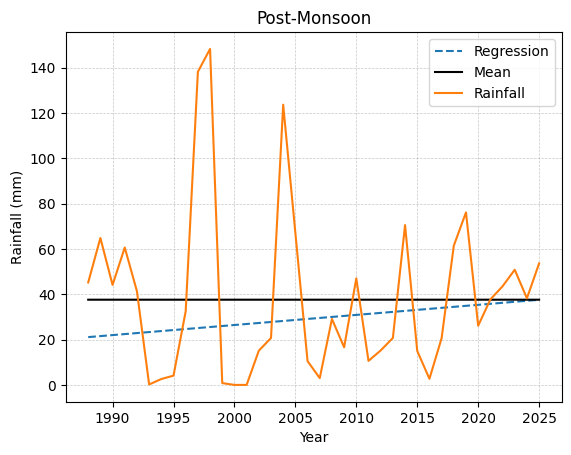

In [49]:
dff = postmon
avg_rainfall=dff.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.plot(dff["TIME"].dt.year,np.ones(dff["TIME"].shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.plot(avg_rainfall["TIME"],avg_rainfall["RF"],label="Rainfall")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Post-Monsoon")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot24.png", dpi=300, bbox_inches="tight")

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.6312218204782534), z=np.float64(-0.48000783692661914), Tau=np.float64(-0.12121212121212122), s=np.float64(-8.0), var_s=212.66666666666666, slope=np.float64(-47.72727272727269), intercept=np.float64(1515.9499999999996))
MEAN:  2896.8583333333336
SD:  3316.843724621437
CV:  114.49796099641635


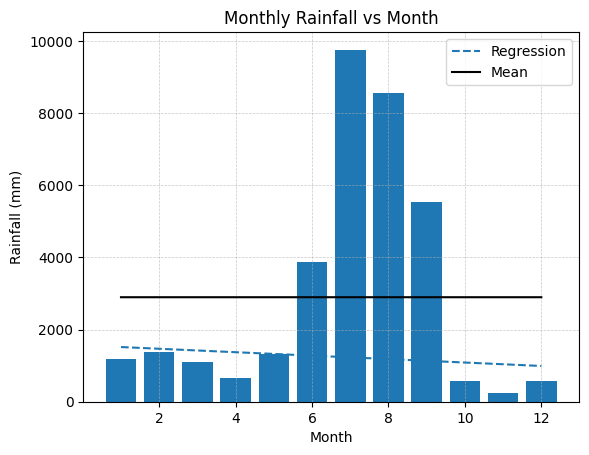

In [50]:
dff = df.dropna(subset=["RF"])
avg_rainfall=df.groupby(df["TIME"].dt.month)["RF"].sum().reset_index()
test=mk.original_test(avg_rainfall["RF"])
print(test)
print("MEAN: ",avg_rainfall["RF"].mean())
print("SD: ",avg_rainfall["RF"].std())
print("CV: ",avg_rainfall["RF"].std()/avg_rainfall["RF"].mean()*100)
plt.plot(avg_rainfall["TIME"],test.slope*(avg_rainfall["TIME"]-avg_rainfall["TIME"].min())+test.intercept,label="Regression",linestyle="--")
plt.plot(df["TIME"].dt.month,np.ones(df["TIME"].dt.month.shape[0])*avg_rainfall["RF"].mean(),c="black",label="Mean")
plt.bar(avg_rainfall["TIME"],avg_rainfall["RF"])
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.title("Monthly Rainfall vs Month")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot25.png", dpi=300, bbox_inches="tight")

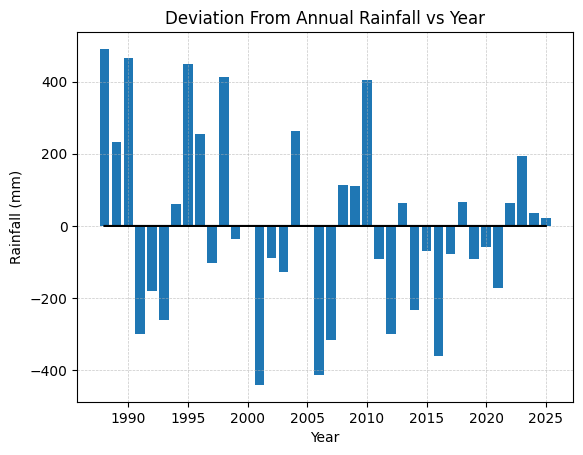

In [51]:
avg_rainfall=df.groupby(df["TIME"].dt.year)["RF"].sum().reset_index()
plt.plot(df["TIME"].dt.year,np.ones(df["TIME"].dt.year.shape[0])*0,c="black")
plt.bar(avg_rainfall["TIME"],avg_rainfall["RF"]-avg_rainfall["RF"].mean())
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.title("Deviation From Annual Rainfall vs Year")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("plot26.png", dpi=300, bbox_inches="tight")

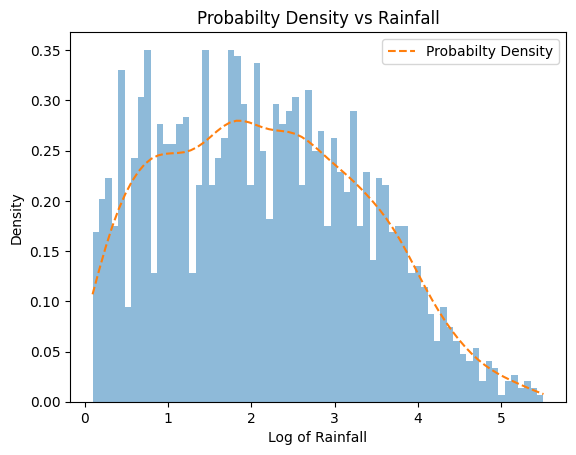

In [52]:
rf=np.array(df[df["RF"]>1]["RF"])
rf=np.log(rf)
plt.hist(rf,bins=70,density=True, alpha=0.5)
from scipy.stats import gaussian_kde
kde = gaussian_kde(rf)

x = np.linspace(rf.min(), rf.max(), 70)
plt.plot(x, kde(x),label="Probabilty Density",linestyle="--")
plt.xlabel("Log of Rainfall")
plt.ylabel("Density")
plt.title("Probabilty Density vs Rainfall")
plt.legend(loc="upper right")
plt.savefig("plot27.png", dpi=300, bbox_inches="tight")

In [56]:
print("Maximum Rainfall : ",dff["RF"].max())
print("Minimum Rainfall : ",dff["RF"].min())

Maximum Rainfall :  246.2
Minimum Rainfall :  0.0


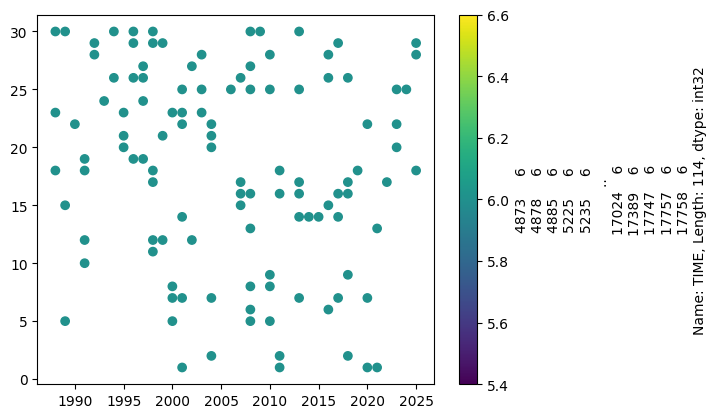

In [53]:
monss=mons[(mons["RF"]>=10)&(mons["TIME"].dt.month==6)]
plt.colorbar(plt.scatter(monss["TIME"].dt.year,monss["TIME"].dt.day,c=monss["TIME"].dt.month), label=monss["TIME"].dt.month)
plt.savefig("plot28.png", dpi=300, bbox_inches="tight")

In [55]:
rainfall_ls={}
for i in df_Years:
    try:
        rainfall_ls[int(i)]=np.where(np.diff(np.array(mons[mons["TIME"].dt.year==int(i)]["RF"]))>4)[0]
    except Exception as e:
        pass

In [56]:
ls={}
for i in rainfall_ls.keys():
    try:
        ls[i]=[rainfall_ls[i][0],rainfall_ls[i][-1],len(rainfall_ls[i])]
    except Exception as e:
        pass

Slope:  [-0.09826258]
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.47698339495731323), z=np.float64(-0.7111627398986167), Tau=np.float64(-0.08258258258258258), s=np.float64(-55.0), var_s=np.float64(5765.666666666667), slope=np.float64(-0.05277777777777778), intercept=np.float64(9.95))


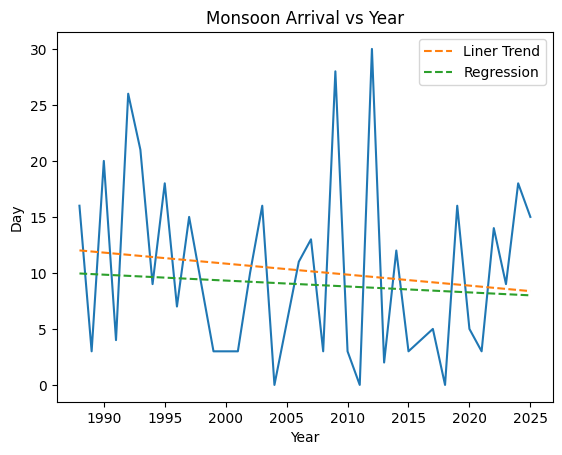

In [57]:
plt.plot(ls.keys(),np.array(list(ls.values()))[:,0])
model.fit(np.array(list(ls.keys())).reshape(-1,1),np.array(list(ls.values()))[:,0])
print("Slope: ",model.coef_)
plt.plot(np.array(list(ls.keys())).reshape(-1,1),model.predict(np.array(list(ls.keys())).reshape(-1,1)),label="Liner Trend",linestyle="--")
test=mk.original_test(np.array(list(ls.values()))[:,0])
print(test)
plt.plot(df_Years,test.slope*(df_Years-df_Years.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("Day")
plt.title("Monsoon Arrival vs Year")
plt.legend(loc="upper right")
plt.savefig("plot29.png", dpi=300, bbox_inches="tight")

Slope:  [0.2090114]
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.27658119486922805), z=np.float64(1.0880315155180265), Tau=np.float64(0.12612612612612611), s=np.float64(84.0), var_s=np.float64(5819.333333333333), slope=np.float64(0.1380952380952381), intercept=np.float64(107.51428571428572))


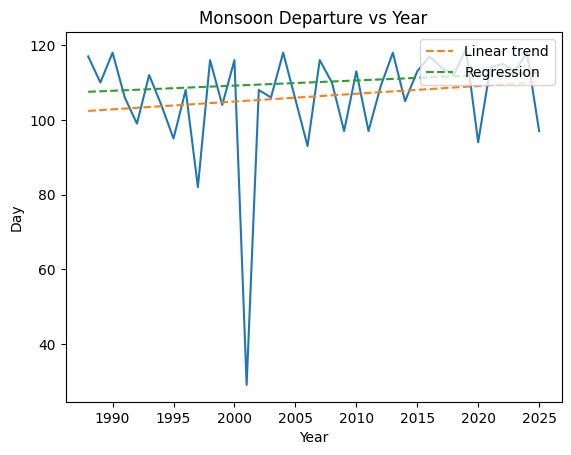

In [61]:
plt.plot(ls.keys(),np.array(list(ls.values()))[:,1])
model=LinearRegression()
model.fit(np.array(list(ls.keys())).reshape(-1,1),np.array(list(ls.values()))[:,1])
print("Slope: ",model.coef_)
plt.plot(np.array(list(ls.keys())).reshape(-1,1),model.predict(np.array(list(ls.keys())).reshape(-1,1)),label="Linear trend",linestyle="--")
test=mk.original_test(np.array(list(ls.values()))[:,1])
print(test)
plt.plot(df_Years,test.slope*(df_Years-df_Years.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("Day")
plt.title("Monsoon Departure vs Year")
plt.legend(loc="upper right")


Slope:  [0.03413892]
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.9790663665191381), z=np.float64(0.0262394294840363), Tau=np.float64(0.0045045045045045045), s=np.float64(3.0), var_s=np.float64(5809.666666666667), slope=np.float64(0.0), intercept=np.float64(19.0))


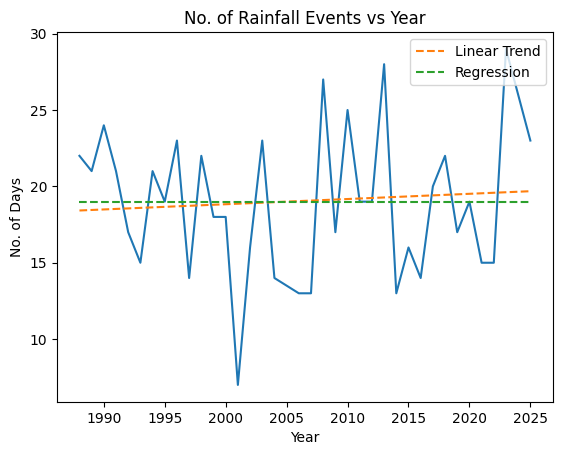

In [62]:
plt.plot(ls.keys(),np.array(list(ls.values()))[:,2])
model=LinearRegression()
model.fit(np.array(list(ls.keys())).reshape(-1,1),np.array(list(ls.values()))[:,2])
print("Slope: ",model.coef_)
plt.plot(np.array(list(ls.keys())).reshape(-1,1),model.predict(np.array(list(ls.keys())).reshape(-1,1)),label="Linear Trend",linestyle="--")
test=mk.original_test(np.array(list(ls.values()))[:,2])
print(test)
plt.plot(df_Years,test.slope*(df_Years-df_Years.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Days")
plt.title("No. of Rainfall Events vs Year")
plt.legend(loc="upper right")

Slope:  [0.30727398]
Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.2769660854491991), z=np.float64(1.0871600444006124), Tau=np.float64(0.12612612612612611), s=np.float64(84.0), var_s=np.float64(5828.666666666667), slope=np.float64(0.2222222222222222), intercept=np.float64(97.0))


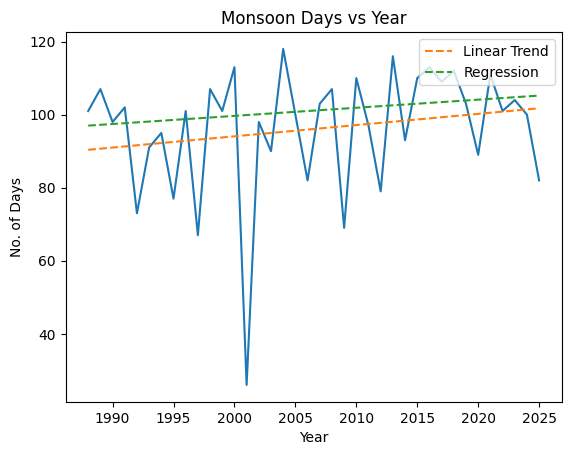

In [63]:
n_days=np.array(list(ls.values()))[:,1]-np.array(list(ls.values()))[:,0]
plt.plot(ls.keys(),n_days)
model=LinearRegression()
model.fit(np.array(list(ls.keys())).reshape(-1,1),n_days)
print("Slope: ",model.coef_)
plt.plot(np.array(list(ls.keys())).reshape(-1,1),model.predict(np.array(list(ls.keys())).reshape(-1,1)),label="Linear Trend",linestyle="--")
test=mk.original_test(n_days)
print(test)
plt.plot(df_Years,test.slope*(df_Years-df_Years.min())+test.intercept,label="Regression",linestyle="--")
plt.xlabel("Year")
plt.ylabel("No. of Days")
plt.title("Monsoon Days vs Year")
plt.legend(loc="upper right")

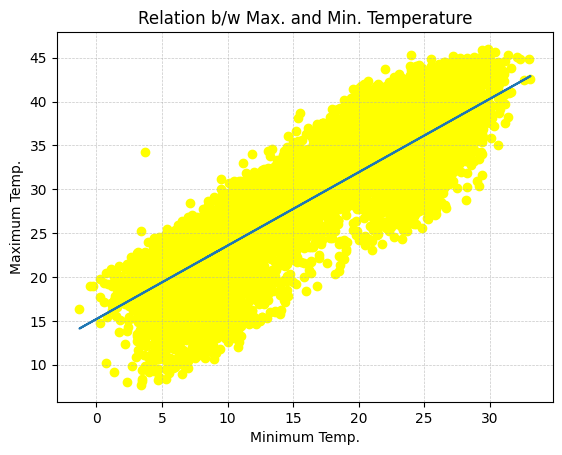

In [64]:
model=LinearRegression()
dff=df.dropna()
model.fit(dff["MIN"].values.reshape(-1, 1),dff["MAX"])
t=model.predict(dff["MIN"].values.reshape(-1, 1))
plt.plot(dff["MIN"],t)
plt.scatter(dff["MIN"],dff["MAX"],c=["yellow"])
plt.xlabel("Minimum Temp.")
plt.ylabel("Maximum Temp.")
plt.title("Relation b/w Max. and Min. Temperature")
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

array([[<Axes: xlabel='MAX', ylabel='MAX'>,
        <Axes: xlabel='MIN', ylabel='MAX'>,
        <Axes: xlabel='RF', ylabel='MAX'>],
       [<Axes: xlabel='MAX', ylabel='MIN'>,
        <Axes: xlabel='MIN', ylabel='MIN'>,
        <Axes: xlabel='RF', ylabel='MIN'>],
       [<Axes: xlabel='MAX', ylabel='RF'>,
        <Axes: xlabel='MIN', ylabel='RF'>,
        <Axes: xlabel='RF', ylabel='RF'>]], dtype=object)

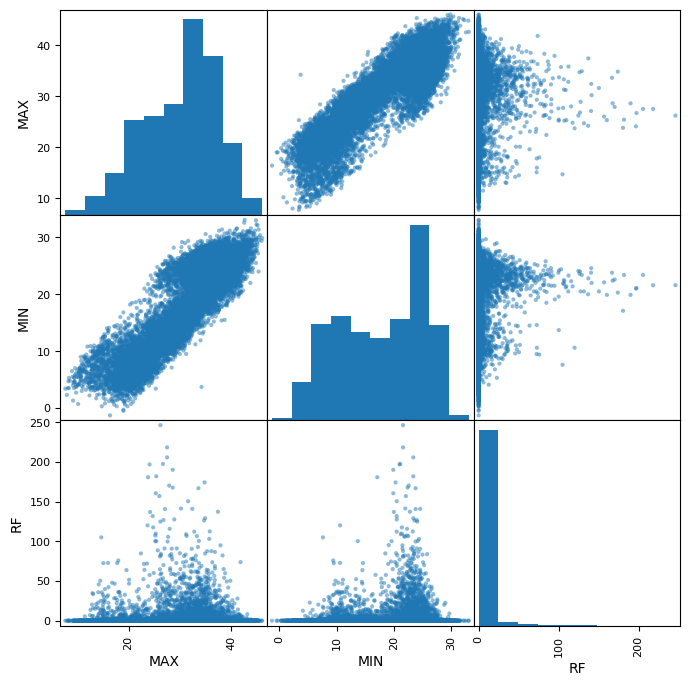

In [65]:
from pandas.plotting import scatter_matrix

scatter_matrix(
    df[["MAX","MIN","RF"]],
    figsize=(8,8)

)

In [66]:
dfExtMonthly.to_csv("extmonthyl.csv",index=False)